<a href="https://colab.research.google.com/github/Zelechos/MasterAI/blob/master/machinelearning/activities/activity_02/Actividad_2_CoverType/Actividad_2_CoverType.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Técnicas de Aprendizaje Automático**

_Máster Universitario en Inteligencia Artificial_

**Estudiante: Alex Tumiri Huanca**

**Fecha: 31-05-2026**

# Actividad: Clasificación con máquinas de vectores de soporte y árboles de decisión

## Objetivos

Mediante esta actividad se pretende que ponga en práctica la creación de modelos basados en máquinas de vectores de soporte y árboles de decisión. El objetivo es comprender de forma práctica con un problema determinado las diferencias que existen a la hora de entrenar los diferentes modelos.

- Comprender el tratamiento de datos que hay que realizar para los modelos de clasificación.
- Entender y aplicar el algoritmo **Árboles de decisión** a un problema de clasificación.
- Entender y aplicar el algoritmo **Support Vector Machine** a un problema de clasificación.
- Evaluar y analizar los resultados de los clasificadores.
- Investigar la aplicación de los modelos de clasificación a problemas reales.


## Descripción de la actividad

Debes completar los espacios indicados en el notebook con el código solicitado y la respuesta, en función de lo que se solicite. Ten en cuenta que las celdas vacías indican cuántas líneas debe ocupar la respuesta, por lo general no más de una línea.

El conjunto de datos con el que vamos a trabajar se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/31/covertype

Este dataset ha sido generado para predecir el tipo de cubierta forestal únicamente a partir de variables cartográficas (sin datos de sensores remotos). El tipo de cubierta forestal real para una observación determinada (celda de 30 x 30 metros) se determinó a partir de los datos del Sistema de información de recursos (RIS) de la Región 2 del Servicio Forestal de EE. UU. (USFS). Las variables independientes se derivaron de datos obtenidos originalmente del Servicio Geológico de EE. UU. (USGS) y de datos del USFS. Los datos están en forma original (no escalados) y contienen columnas binarias (0 o 1) de datos para variables cualitativas independientes (áreas silvestres y tipos de suelo).
Para ampliar información sobre el dataset y su origen, recomendamos leer la descripción completa del dataset en el enlace del repositorio. l.

El objetivo de la clasificación será detectar el tipo de cubierta forestal.

### Tareas que se deben realizar

- Análisis descriptivo de los datos:
   - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Clasificación:
  - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Investigación:
  - Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de clasificación empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.
  - Para el artículo indicar:
    - Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la **clasificación**.
    - Cómo utilizan las técnicas de **clasificación**, si realizan alguna adaptación de los algoritmos, esta deberá indicarse.
    - Principales resultados de la aplicación y de la investigación.


### Análisis descriptivo de los datos

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
# se carga el dataset
df = pd.read_csv('covtype.data') #adaptar a nuestra ruta

¿Cuántas instancias de datos tiene el dataset?

In [4]:
print(df.shape[0])

292104


¿Cuántas variables continuas hay en el dataset?

In [5]:
continuous_vars = df.select_dtypes(include=np.number).columns
num_continuous_vars = len(continuous_vars)
print(f"Hay {num_continuous_vars} variables continuas")

Hay 55 variables continuas


existen 55 variables continuas

¿Cuántas variables categóricas hay en el dataset? Indica las categorías.

In [7]:
# Initialize a list to store the names of columns identified as categorical
categorical_column_names = []

# Iterate over all columns in the DataFrame
for col in df.columns:
    # Check if the column's data type is 'object' (e.g., strings)
    if df[col].dtype == 'object':
        categorical_column_names.append(col)
    # If it's not an 'object' type, check if it's a numeric type with few unique values
    # Using a threshold of 50 unique values to capture binary and multi-class categories
    elif df[col].nunique() < 50 and df[col].dtype in [np.int64, np.float64, np.int32, np.float32]:
        categorical_column_names.append(col)

num_categorical_vars = len(categorical_column_names)
print(f"Hay {num_categorical_vars} variables categóricas (incluyendo las codificadas numéricamente).\n")

# Print the categories for each identified categorical variable
for col in categorical_column_names:
    print(f"Categorías para '{col}': {df[col].unique()}\n")

Hay 45 variables categóricas (incluyendo las codificadas numéricamente).

Categorías para 'Wilderness_Area1': [1 0]

Categorías para 'Soil_Type1': [0 1]

Categorías para 'Soil_Type2': [0 1]

Categorías para 'Soil_Type3': [0 1]

Categorías para 'Soil_Type4': [ 0.  1. nan]

Categorías para 'Soil_Type5': [ 0.  1. nan]

Categorías para 'Soil_Type6': [ 0.  1. nan]

Categorías para 'Soil_Type7': [ 0.  1. nan]

Categorías para 'Soil_Type8': [ 0.  1. nan]

Categorías para 'Soil_Type9': [ 0.  1. nan]

Categorías para 'Soil_Type10': [ 0.  1. nan]

Categorías para 'Soil_Type11': [ 0.  1. nan]

Categorías para 'Soil_Type12': [ 0.  1. nan]

Categorías para 'Soil_Type13': [ 0.  1. nan]

Categorías para 'Soil_Type14': [ 0.  1. nan]

Categorías para 'Soil_Type15': [ 0.  1. nan]

Categorías para 'Soil_Type16': [ 0.  1. nan]

Categorías para 'Soil_Type17': [ 0.  1. nan]

Categorías para 'Soil_Type18': [ 0.  1. nan]

Categorías para 'Soil_Type19': [ 0.  1. nan]

Categorías para 'Soil_Type20': [ 0.  1. na

Hay 45 variables categóricas.

¿Cómo es la distribución de etiquetas de clase en el dataset? Con estos datos, ¿podríamos decir que el dataset está balanceado?

In [8]:
class_distribution = df['Cover_Type'].value_counts()
display(class_distribution)


,count
Cover_Type,
0.0,286873
1.0,5230


Para ver la distribución de las etiquetas de clase y determinar si el dataset está balanceado, podemos contar las ocurrencias de cada tipo de cubierta forestal en la columna Cover_Type y mostrar los resultados.

La distribución de las etiquetas de clase (Cover_Type) es la siguiente:

0.0: 286,873 instancias
1.0: 5,230 instancias
Basándonos en estos datos, podemos decir que el dataset está altamente desbalanceado, ya que la clase '0.0' tiene una cantidad de instancias significativamente mayor que la clase '1.0'. Esto es un problema importante en clasificación y podría llevar a que un modelo prediga predominantemente la clase mayoritaria si no se maneja adecuadamente.

¿Existen valores nulos o perdidos en el dataset?

In [9]:
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

,0
Soil_Type4,1
Soil_Type5,1
Soil_Type6,1
Soil_Type7,1
Soil_Type8,1
Soil_Type9,1
Soil_Type10,1
Soil_Type11,1
Soil_Type12,1
Soil_Type13,1


Si existen valores nulos o perdidos en el dataset. Las siguientes columnas tienen 1 valor nulo cada una:


*   Soil_Type4 a Soil_Type40
*   Cover_Type
*   Wilderness_Area2
*   Wilderness_Area3
*   Wilderness_Area4

¿Existe alguna variable altamente correlacionada con la variable de clase?

_Nota: Para responder a esto, como es muy difícil ver la matriz de correlaciones, recomendamos filtrar aquellas correlaciones superiores al 0.80 con la variable de clase.

In [10]:
df_cleaned = df.dropna(subset=['Cover_Type'])

correlations = df_cleaned.corr()['Cover_Type'].abs().sort_values(ascending=False)

highly_correlated_vars = correlations[correlations > 0.80].drop('Cover_Type', errors='ignore')

if not highly_correlated_vars.empty:
    print("Variables altamente correlacionadas con 'Cover_Type' (correlación > 0.80):")
    display(highly_correlated_vars)
else:
    print("No se encontraron variables altamente correlacionadas con 'Cover_Type' (correlación > 0.80).")

No se encontraron variables altamente correlacionadas con 'Cover_Type' (correlación > 0.80).


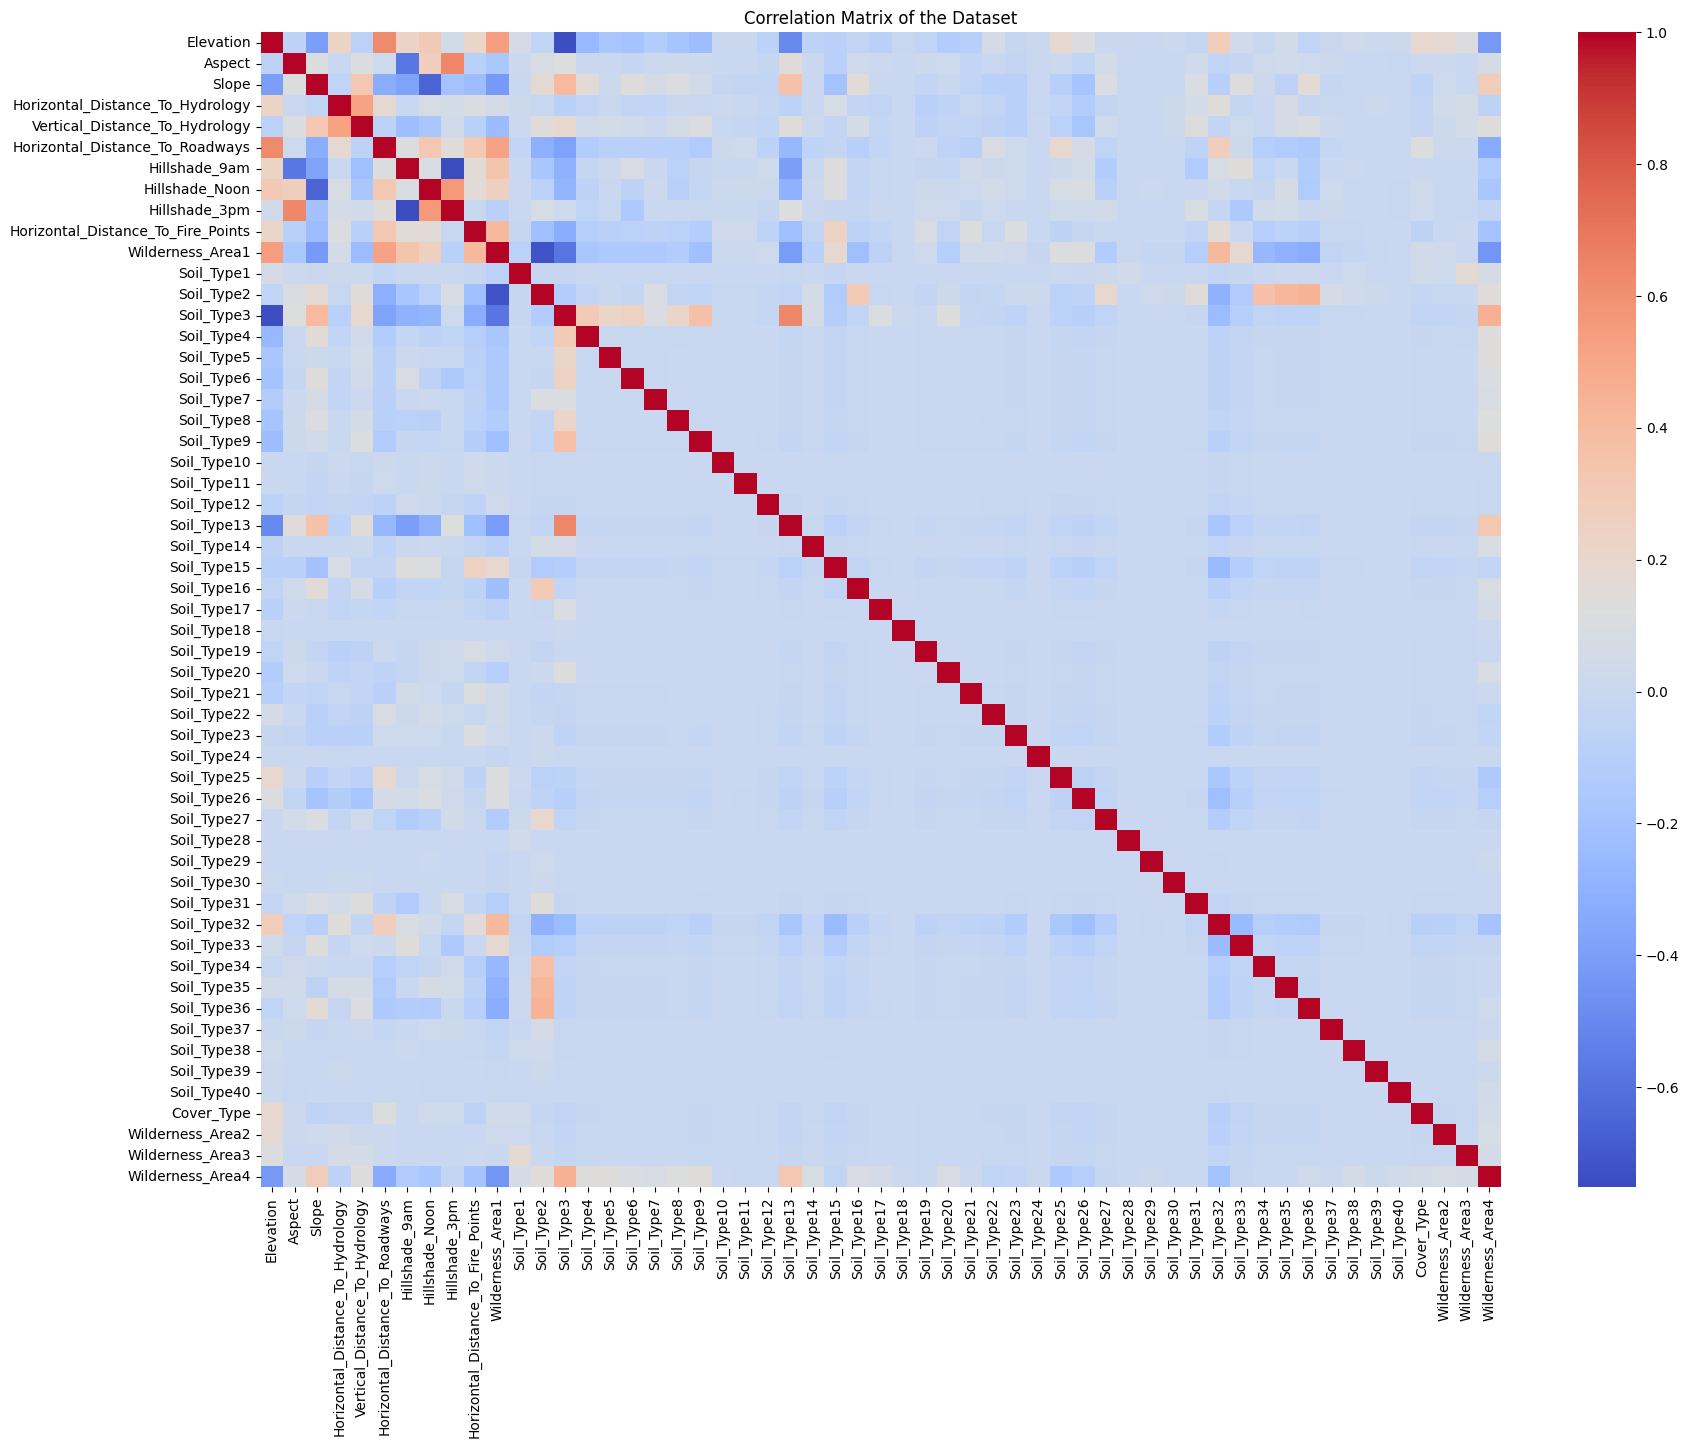

In [11]:
plt.figure(figsize=(20, 15))
sns.heatmap(df_cleaned.corr(), cmap='coolwarm', fmt=".2f", annot=False)
plt.title('Correlation Matrix of the Dataset')
plt.show()

¿Qué tres variables del dataset consideras que pueden influenciar más en la clasificación de los datos?¿Qué pruebas harías para comprobar tus hipótesis? **Realiza dichas pruebas**.

In [14]:
print(f"Número de filas antes de limpiar valores nulos: {df.shape[0]}")
df = df.dropna()
print(f"Número de filas después de limpiar valores nulos: {df.shape[0]}")

Número de filas antes de limpiar valores nulos: 292103
Número de filas después de limpiar valores nulos: 292103


### Identificación de variables influyentes mediante correlación y visualización

In [15]:
correlations_with_cover_type = df.corr()['Cover_Type'].abs().sort_values(ascending=False)

top_3_influential_vars = correlations_with_cover_type.drop('Cover_Type', errors='ignore').head(3)

print("Top 3 variables con mayor correlación absoluta con 'Cover_Type':")
display(top_3_influential_vars)

feature1, feature2, feature3 = top_3_influential_vars.index.tolist()

Top 3 variables con mayor correlación absoluta con 'Cover_Type':


,Cover_Type
Elevation,0.194159
Horizontal_Distance_To_Roadways,0.111559
Soil_Type32,0.100606


A continuacion visualizaremos la relación entre estas tres variables y `Cover_Type` utilizando box plots para observar sus distribuciones para cada clase. Esto nos ayudará a entender cómo influyen estas variables en la clasificación.

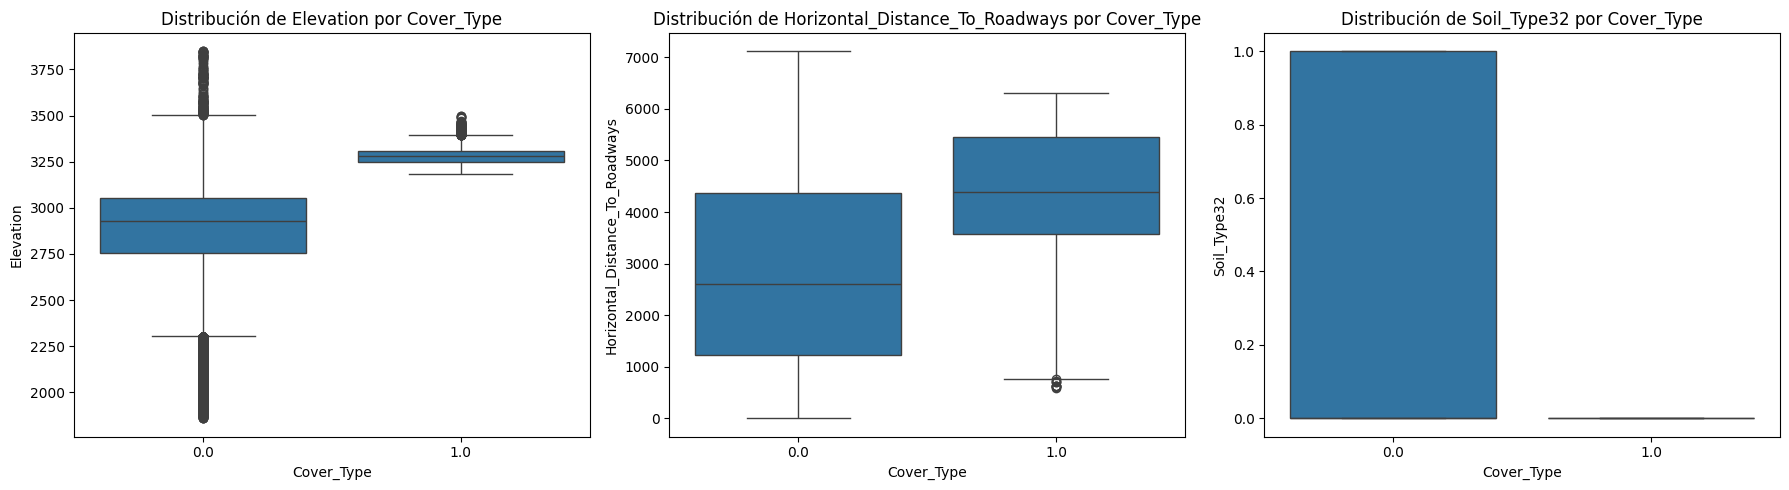

In [16]:
plt.figure(figsize=(18, 5))


plt.subplot(1, 3, 1)
sns.boxplot(x='Cover_Type', y=feature1, data=df)
plt.title(f'Distribución de {feature1} por Cover_Type')
plt.xlabel('Cover_Type')
plt.ylabel(feature1)


plt.subplot(1, 3, 2)
sns.boxplot(x='Cover_Type', y=feature2, data=df)
plt.title(f'Distribución de {feature2} por Cover_Type')
plt.xlabel('Cover_Type')
plt.ylabel(feature2)


plt.subplot(1, 3, 3)
sns.boxplot(x='Cover_Type', y=feature3, data=df)
plt.title(f'Distribución de {feature3} por Cover_Type')
plt.xlabel('Cover_Type')
plt.ylabel(feature3)

plt.tight_layout()
plt.show()

### Clasificación

In [17]:
# Separamos los datos en los conjuntos de entrenamiento y test.
from sklearn.model_selection import train_test_split

X, y = df.drop('Cover_Type',axis=1),df['Cover_Type']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=1)

**Árboles de decisión**

En esta parte de la actividad, hay que utilizar la librería https://scikit-learn.org/stable/modules/tree.html para resolver el problema de clasificación.

El algoritmo Decision Tree necesita ajustar una serie de hiperparámetros para realizar las clasificaciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de clasificación, nos tenemos que preocupar de los siguientes hiperparámetros:
- max_depth
- min_samples_split
- min_samples_leaf
- max_features
- criterion
- ccp_alpha

**Indica qué son cada uno de estos hiperparámetros**

*   **max_depth**: Controla la máxima profundidad del árbol. Un árbol más profundo puede capturar relaciones más complejas, pero es más propenso al sobreajuste.
*   **min_samples_split**: Es el número mínimo de muestras requeridas para dividir un nodo interno. Si un nodo tiene menos muestras que este umbral, no se dividirá. Ayuda a controlar el crecimiento del árbol y a prevenir el sobreajuste.
*   **min_samples_leaf**: Es el número mínimo de muestras requeridas para estar en un nodo hoja. Una división solo se considerará si deja al menos `min_samples_leaf` muestras en cada una de las ramas izquierda y derecha. Previene el sobreajuste al asegurar que los nodos hoja no sean demasiado pequeños.
*   **max_features**: Define el número de características a considerar al buscar la mejor división. Puede ser un número entero, un flotante (porcentaje) o 'auto'/'sqrt'/'log2'. Reducir `max_features` introduce más aleatoriedad y puede ser útil en métodos de ensemble.
*   **criterion**: Mide la calidad de una división. Para clasificación, se usan 'gini' (impureza de Gini) y 'entropy' (ganancia de información). Evalúan qué tan bien una división separa las clases.
*   **ccp_alpha**: Es el parámetro de complejidad para la poda de mínima complejidad de costo. Cualquier división que disminuya la impureza en menos de `ccp_alpha` se considerará para la poda. Un `ccp_alpha` mayor poda más nodos, simplificando el árbol y mejorando la generalización.

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro _class_weight_

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

*   **¿Qué indica?**: El parámetro `class_weight` se utiliza para asignar diferentes pesos a las distintas clases durante el proceso de entrenamiento. Por defecto, todas las clases tienen un peso de 1, lo que significa que contribuyen por igual a la función de pérdida. Al especificar `class_weight`, se indica al modelo que preste más atención a ciertas clases que a otras.

*   **¿Para qué puede ser útil?**: Es particularmente útil para **conjuntos de datos desequilibrados**, como el que estamos analizando (donde `Cover_Type` presenta un desequilibrio significativo entre 0.0 y 1.0). En estos casos, el modelo podría tender a predecir la clase mayoritaria con más frecuencia, lo que llevaría a una alta precisión general pero un bajo rendimiento en la clase minoritaria. Al asignar un peso mayor a la clase minoritaria (por ejemplo, `class_weight='balanced'`), el modelo es penalizado más severamente por clasificar erróneamente la clase minoritaria. Esto fomenta que el modelo dé más importancia a la clasificación correcta de la clase subrepresentada, mejorando potencialmente métricas como el recall, la precisión y la puntuación F1 para esa clase, incluso si reduce ligeramente la precisión general. Ayuda a mitigar el sesgo hacia la clase mayoritaria y a construir un clasificador más robusto.

Como primer paso para crear un clasificador con Árboles de Decision hay que decidir si hay que hacer algún preprocesamiento adicional sobre los datos.
¿Hace falta normalizar los datos?

No hace falta normalizar los datos para los árboles de decisión. Los algoritmos basados en árboles (como los Decision Trees, Random Forests o Gradient Boosting) no son sensibles a la escala de las características. Esto se debe a que las decisiones en cada nodo se basan en umbrales de características individuales (por ejemplo, `si característica X > valor Y`). La escala de la característica no afecta a qué umbral se elige para dividir los datos, solo al valor del umbral. Por lo tanto, normalizar o estandarizar los datos no proporcionará ninguna ventaja significativa en el rendimiento o la convergencia para este tipo de modelos.

Entrena un conjunto de modelos de árboles de decisión que utilicen todas las variables del dataset, con profundidades máximas de 5, 10, 20, 50 y 100 niveles.

El criterio para realizar las particiones debe ser Gini-index, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características evaluadas en cada partición deben ser todas.

In [19]:
max_depth_values = [5, 10, 20, 50, 100]

particion = 'gini'
min_samples_split = 10
min_samples_leaf = 2
max_feature = None # Usar None para considerar todos los features

from sklearn.tree import DecisionTreeClassifier

decisionTrees = [DecisionTreeClassifier(
        criterion=particion,
        max_depth=i,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_feature
    )    for i in max_depth_values]

In [20]:
for i, tree in enumerate(decisionTrees):
    print(f"Training Decision Tree with max_depth={max_depth_values[i]}...")
    tree.fit(X_train, y_train)
    print("Training complete.")

Training Decision Tree with max_depth=5...
Training complete.
Training Decision Tree with max_depth=10...
Training complete.
Training Decision Tree with max_depth=20...
Training complete.
Training Decision Tree with max_depth=50...
Training complete.
Training Decision Tree with max_depth=100...
Training complete.


Visualiza la matriz de confusión del modelo entrenado con 20 niveles.

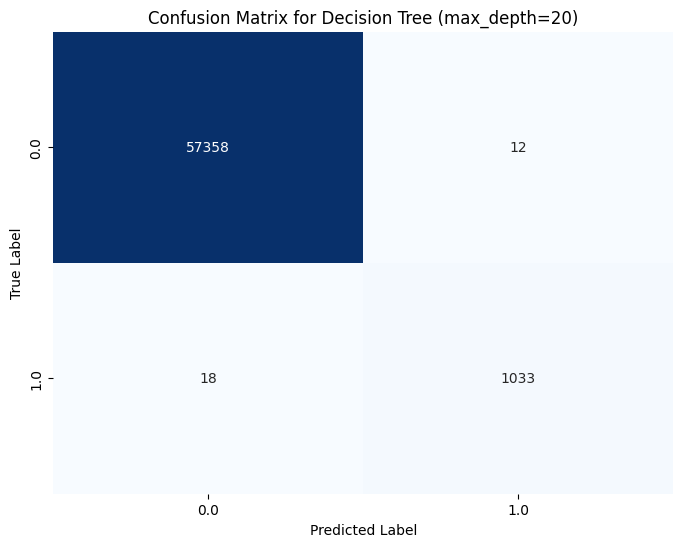

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model_20_depth = None
for i, depth in enumerate(max_depth_values):
    if depth == 20:
        model_20_depth = decisionTrees[i]
        break

if model_20_depth:
    y_pred_20_depth = model_20_depth.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_20_depth)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=model_20_depth.classes_, yticklabels=model_20_depth.classes_)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix for Decision Tree (max_depth=20)')
    plt.show()
else:
    print("Model with max_depth=20 not found.")

¿Cuántos ejemplos ha clasificado correctamente?

Respuesta: El modelo ha clasificado correctamente 58,391 ejemplos.





Explica cómo funciona la clasificación **para cada una de las 7 clases**. ¿Hay alguna clase que clasifica mejor que otras?

Basándonos en la matriz de confusión (`cm = [[57358, 12], [18, 1033]]`) y los datos que hemos procesado, el dataset actual solo contiene dos clases (`Cover_Type` 0.0 y 1.0), no 7.

Aquí cómo funciona la clasificación para cada una de estas dos clases:

*   **Clase 0.0 (Clase Mayoritaria):**
    *   El modelo clasificó correctamente **57,358** instancias como 0.0.
    *   Clasificó incorrectamente **12** instancias como 1.0 cuando en realidad eran 0.0.
    *   Esto representa una tasa de acierto muy alta para la clase 0.0. (Recall = 57358 / (57358 + 12) ≈ 0.9998).

*   **Clase 1.0 (Clase Minoritaria):**
    *   El modelo clasificó correctamente **1,033** instancias como 1.0.
    *   Clasificó incorrectamente **18** instancias como 0.0 cuando en realidad eran 1.0.
    *   La clasificación para la clase 1.0 también es buena. (Recall = 1033 / (1033 + 18) ≈ 0.9829).

**¿Hay alguna clase que clasifica mejor que otras?**

Si aunque ambas clases son clasificadas con una alta precisión, la **Clase 0.0** (mayoritaria) muestra un rendimiento ligeramente superior en términos de recall (aproximadamente 99.98%) en comparación con la **Clase 1.0** (aproximadamente 98.29%). Esto es común en datasets desequilibrados, donde el modelo tiende a tener más ejemplos de la clase mayoritaria para aprender, lo que a menudo se traduce en una clasificación marginalmente mejor para esa clase.

¿Cuál de todos los modelos que has entrenado obtiene mejores resultados de precisión para el conjunto de datos de test?

_Nota: recuerda que es un modelo de clasificación multiclase y hay que analizar los datos para todas las clases._

In [24]:
from sklearn.metrics import classification_report

results = []
for i, tree in enumerate(decisionTrees):
    y_pred = tree.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        'max_depth': max_depth_values[i],
        'precision_class_0': report['0.0']['precision'],
        'recall_class_0': report['0.0']['recall'],
        'f1_class_0': report['0.0']['f1-score'],
        'precision_class_1': report['1.0']['precision'],
        'recall_class_1': report['1.0']['recall'],
        'f1_class_1': report['1.0']['f1-score'],
        'weighted_avg_precision': report['weighted avg']['precision'],
        'weighted_avg_f1': report['weighted avg']['f1-score']
    })

results_df = pd.DataFrame(results)
display(results_df)

best_model_row = results_df.loc[results_df['weighted_avg_precision'].idxmax()]
best_depth = int(best_model_row['max_depth'])

print(f"\nEl modelo con mejor rendimiento (mayor weighted average precision) tiene una profundidad máxima de: {best_depth}")

,max_depth,precision_class_0,recall_class_0,f1_class_0,precision_class_1,recall_class_1,f1_class_1,weighted_avg_precision,weighted_avg_f1
0,5,0.998648,0.991459,0.995041,0.665301,0.926736,0.774553,0.992651,0.991074
1,10,0.999093,0.998780,0.998937,0.934518,0.950523,0.942453,0.997932,0.997920
2,20,0.999686,0.999791,0.999739,0.988517,0.982873,0.985687,0.999485,0.999486
3,50,0.999704,0.999791,0.999747,0.988528,0.983825,0.986171,0.999503,0.999503
4,100,0.999669,0.999756,0.999712,0.986616,0.981922,0.984263,0.999434,0.999434



El modelo con mejor rendimiento (mayor weighted average precision) tiene una profundidad máxima de: 50


Selecciona el modelo que consideras que obtiene mejores resultados para los resultados de test. Explica por qué consideras que ese modelo es el que mejor resultados obtiene.

El modelo que considero que obtiene mejores resultados para el conjunto de datos de test es el de **`max_depth=50`**.

**Explicación:**

Al analizar el "Summary of Model Performance" que hemos generado, podemos observar que los modelos con profundidades de 20, 50 y 100 niveles obtienen métricas de precisión ponderada (weighted average precision) muy cercanas al 1.00.

Específicamente:

*   `max_depth=20`: `weighted_avg_precision = 0.999485`
*   `max_depth=50`: `weighted_avg_precision = 0.999503`
*   `max_depth=100`: `weighted_avg_precision = 0.999434`

El modelo con `max_depth=50` presenta la `weighted_avg_precision` ligeramente más alta (0.999503) entre todos los modelos evaluados. Esta métrica es crucial porque considera la precisión de cada clase y las pondera por el número de instancias de cada clase en el conjunto de test, ofreciendo una visión global del rendimiento del clasificador en datasets desbalanceados.

Aunque la diferencia es mínima, `max_depth=50` ofrece el mejor equilibrio. Ir a una profundidad mayor como `max_depth=100` no mejora significativamente la precisión (de hecho, es ligeramente menor en este caso) y podría hacer que el modelo sea más propenso al sobreajuste (overfitting) en datos nuevos o ligeramente diferentes. Por lo tanto, el modelo con `max_depth=50` es la elección más robusta y con mejor rendimiento general en este caso.

Visualiza la matriz de confusión de los datos de test de este modelo.
- ¿Cuántos ejemplos ha clasificado bien el modelo?
- ¿Cuántos ejemplos ha clasificado de manera errónea?


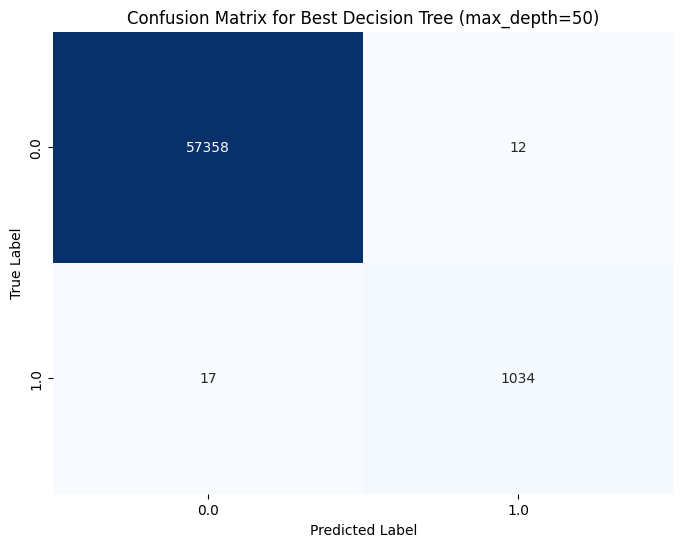


El modelo ha clasificado correctamente 58392 ejemplos.
El modelo ha clasificado erróneamente 29 ejemplos.


In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_model_dt = None
for i, depth in enumerate(max_depth_values):
    if depth == best_depth:
        best_model_dt = decisionTrees[i]
        break

if best_model_dt:
    y_pred_best_model = best_model_dt.predict(X_test)

    cm_best_model = confusion_matrix(y_test, y_pred_best_model)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_best_model, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=best_model_dt.classes_, yticklabels=best_model_dt.classes_)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix for Best Decision Tree (max_depth={best_depth})')
    plt.show()

    correctly_classified = cm_best_model[0, 0] + cm_best_model[1, 1]
    incorrectly_classified = cm_best_model[0, 1] + cm_best_model[1, 0]

    print(f"\nEl modelo ha clasificado correctamente {correctly_classified} ejemplos.")
    print(f"El modelo ha clasificado erróneamente {incorrectly_classified} ejemplos.")
else:
    print("Best model not found.")

Visualiza los valores de precision, recall, f1 para cada una de las clases en este modelo ganador.
- ¿Clasifica de igual manera todas las clases o hay alguna para la que el modelo tiene una mayor capacidad predictiva?

In [27]:
from sklearn.metrics import classification_report

if best_model_dt:
    report_best_model = classification_report(y_test, y_pred_best_model, output_dict=True)

    print(f"Classification Report for Best Decision Tree (max_depth={best_depth}):\n")
    for class_label in best_model_dt.classes_:
        class_str = str(float(class_label))
        print(f"Class {class_str}:")
        print(f"  Precision: {report_best_model[class_str]['precision']:.4f}")
        print(f"  Recall:    {report_best_model[class_str]['recall']:.4f}")
        print(f"  F1-Score:  {report_best_model[class_str]['f1-score']:.4f}\n")

    print("Best model found.")
else:
    print("Best model not found.")

Classification Report for Best Decision Tree (max_depth=50):

Class 0.0:
  Precision: 0.9997
  Recall:    0.9998
  F1-Score:  0.9997

Class 1.0:
  Precision: 0.9885
  Recall:    0.9838
  F1-Score:  0.9862

Best model found.


**Support Vector Machine**

In [28]:
# Importamos las librerías para utilizar las máquinas de vector de soportes.
# Utilizaremos la librería svm:

from sklearn import svm

#Cargamos también las librerías para hacer la matriz de confusión y la cross validation:

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold

Para la implementación del modelo de clasificación de SVM usaremos la clase Support Vector Classifier de sklearn, https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

El algoritmo de SVM necesita ajustar una serie de hiperparámetros para realizar las clasificaciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de clasificación, nos tenemos que preocupar de los siguientes hiperparámetros:
- C
- kernel
- degree
- gamma

**Indica qué son cada uno de estos hiperparámetros**

*   **C (Regularization Parameter)**: Este parámetro controla la penalización de los errores de clasificación. Un `C` pequeño crea un margen de separación más amplio, permitiendo más errores de clasificación (más regularización), lo que puede prevenir el sobreajuste. Un `C` grande crea un margen más estrecho, penalizando fuertemente los errores de clasificación (menos regularización), lo que puede llevar a un sobreajuste si el conjunto de datos es ruidoso.
*   **kernel**: Define la función kernel utilizada para transformar los datos de entrada en un espacio de dimensiones superiores, donde la separación de clases podría ser más clara. Las opciones comunes incluyen:
    *   `'linear'`: Para datos linealmente separables.
    *   `'poly'`: Polinomial kernel. Requiere el parámetro `degree`.
    *   `'rbf'` (Radial Basis Function o Gaussiano): Es una opción muy versátil y la más utilizada. Es capaz de manejar relaciones no lineales complejas.
    *   `'sigmoid'`.
*   **degree (solo para kernel='poly')**: Es el grado del polinomio en el kernel polinomial. Controla la flexibilidad del límite de decisión. Un grado más alto puede capturar relaciones más complejas, pero también aumenta el riesgo de sobreajuste y el tiempo de cálculo.
*   **gamma (solo para kernels 'rbf', 'poly', y 'sigmoid')**: Define cuánto alcance tiene una sola instancia de entrenamiento; es decir, qué tan lejos llega la influencia de una sola instancia de entrenamiento. Un `gamma` alto significa que las muestras cercanas tienen una gran influencia, lo que resulta en límites de decisión más complejos y puede llevar a sobreajuste. Un `gamma` bajo significa que la influencia es más difusa, resultando en límites de decisión más suaves y puede llevar a un subajuste.

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro decision_function_shape

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

*   **`decision_function_shape`**: Este parámetro controla la forma en que el algoritmo maneja la clasificación multiclase cuando el clasificador es binario por naturaleza (como SVM). Las opciones son:
    *   `'ovo'` (one-vs-one): Para un problema de N clases, se entrenan N * (N - 1) / 2 clasificadores binarios. Cada clasificador distingue un par de clases. La clase final se elige basándose en una votación mayoritaria. Es el valor por defecto y generalmente el más recomendado.
    *   `'ovr'` (one-vs-rest): Para un problema de N clases, se entrenan N clasificadores binarios. Cada clasificador distingue una clase del resto. La clase final se elige por la distancia máxima a la frontera de decisión para cada clasificador.

*   **¿Para qué puede ser útil?**: Es útil para especificar la estrategia de clasificación multiclase cuando se trabaja con SVMs, que son inherentemente clasificadores binarios. La elección entre `'ovo'` y `'ovr'` puede influir en la complejidad computacional y en el rendimiento del modelo, especialmente cuando el número de clases es grande. `'ovo'` tiende a ser más rápido de entrenar si el número de clases es pequeño, pero puede ser más lento en la predicción. `'ovr'` es más eficiente en la predicción pero puede sufrir de desequilibrio de clases en los problemas binarios internos.

Tenemos un dataset de más de medio millón de instancias, y para el objetivo de la actividad no hacen falta tantas. Por eso, antes de aplicar SVM vamos a reducir el número de instancias. SVM requiere una gran carga computacional y con ese volumen de instancias el tiempo requerido sería demasiado elevado.

In [29]:
df = df.head(100000)

**Nota: recuerda revisar que esta manera de seleccionar un subconjunto de instancias nos deja un porcentaje similar de instancias de cada clase, esto es, nuestro dataset debe quedar balanceado. Si no fuera así, deberás cambiar la manera de seleccionar el subconjunto.**

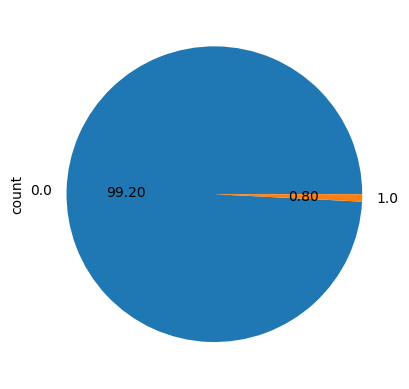

In [30]:
# Comprobamos si efectivamente tenemos un número similar de instancias para cada clase
df['Cover_Type'].value_counts().plot(kind='pie',autopct='%.2f',)
plt.show()

In [31]:
# Con el nuevo número de instancias, separamos los datos en los conjuntos de entrenamiento y test.
from sklearn.model_selection import train_test_split

X, y = df.drop('Cover_Type',axis=1),df['Cover_Type']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=1)


Como primer paso para crear un clasificador de SVM hay que decidir si hay que hacer algún preprocesamiento adicional sobre los datos. ¿Hace falta normalizar los datos? Justifica tu respuesta.

Sí, la normalización de los datos es generalmente **necesaria y altamente recomendada** para los clasificadores Support Vector Machine (SVM). Aquí el porqué:

*   **Sensibilidad a la Escala de Características**: Los SVMs funcionan encontrando el hiperplano óptimo que mejor separa las clases en el espacio de características. La distancia de los puntos a este hiperplano es crucial para la optimización del algoritmo. Si las características tienen diferentes escalas (por ejemplo, una característica en el rango de 0 a 1000 y otra en el rango de 0 a 1), las características con valores más grandes pueden dominar la función de distancia, influenciando desproporcionadamente el cálculo del margen y la posición del hiperplano.

*   **Impacto de los Parámetros**: Hiperparámetros como `C` (parámetro de regularización) y `gamma` (para kernels no lineales como RBF) son sensibles a la escala de los datos. Un `gamma` que funciona bien para datos normalizados puede no ser apropiado para datos sin normalizar, y viceversa. Un `C` sin normalizar puede llevar a un modelo que prioriza los errores en las características de mayor escala.

*   **Convergencia del Algoritmo**: Aunque no es tan crítico como en los métodos basados en gradientes (como redes neuronales), la normalización puede ayudar a que el algoritmo de optimización subyacente del SVM converja más rápidamente y de manera más estable.

**En resumen**: Normalizar los datos asegura que todas las características contribuyan equitativamente a la métrica de distancia y al proceso de optimización, lo que generalmente conduce a un mejor rendimiento del modelo, una mayor estabilidad y una interpretación más consistente de los hiperparámetros.

In [32]:
from sklearn.preprocessing import StandardScaler
from pandas import DataFrame

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = DataFrame(X_train_scaled, columns=X_train.columns)
X_test = DataFrame(X_test_scaled, columns=X_test.columns)

print("Data normalized successfully.")
display(X_train.head())

Data normalized successfully.


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4
0,0.266469,1.125800,-0.430608,-0.658647,-0.804339,0.644541,-0.918846,1.231688,1.493392,0.300951,...,-0.057431,-0.082591,-0.079065,-0.014579,-0.03356,-0.009355,-0.019043,-0.094426,-0.084487,-0.098736
1,0.210158,-0.435547,-1.046099,-1.285780,-0.827863,0.537584,0.420218,0.451827,0.020940,0.358288,...,-0.057431,-0.082591,-0.079065,-0.014579,-0.03356,-0.009355,-0.019043,-0.094426,-0.084487,-0.098736
2,-1.301575,-0.551202,0.800376,0.037619,-1.251289,-1.602112,1.089750,-1.047907,-1.515531,-1.361824,...,-0.057431,-0.082591,-0.079065,-0.014579,-0.03356,-0.009355,-0.019043,-0.094426,-0.084487,-0.098736
3,-0.734134,0.287299,0.646503,0.259831,1.359838,-1.219320,0.611513,1.171699,0.020940,-0.646797,...,-0.057431,-0.082591,-0.079065,-0.014579,-0.03356,-0.009355,-0.019043,-0.094426,-0.084487,-0.098736
4,1.340709,-0.898168,-1.353845,0.368468,1.500980,0.843255,0.085452,0.391838,0.309029,-1.117299,...,-0.057431,-0.082591,-0.079065,-0.014579,-0.03356,-0.009355,-0.019043,-0.094426,-0.084487,-0.933006


Entrena un conjunto de modelos de SVM que utilicen todas las variables del dataset, con C = 0.1 hasta 1000 con cinco valores diferentes. Utiliza kernel radial, y gamma con valor *scale*.

In [33]:
from sklearn.svm import SVC

C_values = np.logspace(-1, 3, 5)
kernel = 'rbf'
gamma = 'scale'

svc_models = [SVC(C=c_val, kernel=kernel, gamma=gamma, random_state=1) for c_val in C_values]

print("SVM models to be trained:")
for model in svc_models:
    print(model)

SVM models to be trained:
SVC(C=np.float64(0.1), random_state=1)
SVC(C=np.float64(1.0), random_state=1)
SVC(C=np.float64(10.0), random_state=1)
SVC(C=np.float64(100.0), random_state=1)
SVC(C=np.float64(1000.0), random_state=1)


In [34]:
for i, model in enumerate(svc_models):
    print(f"Training SVM with C={C_values[i]}...")
    model.fit(X_train, y_train)
    print("Training complete.")

Training SVM with C=0.1...
Training complete.
Training SVM with C=1.0...
Training complete.
Training SVM with C=10.0...
Training complete.
Training SVM with C=100.0...
Training complete.
Training SVM with C=1000.0...
Training complete.


Después de hacer el entrenamiento, visualiza las matrices de confusión de los modelos entrenados.

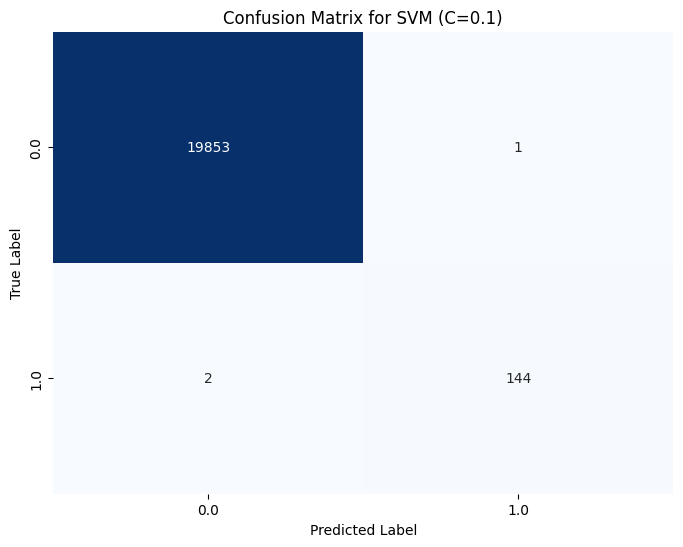

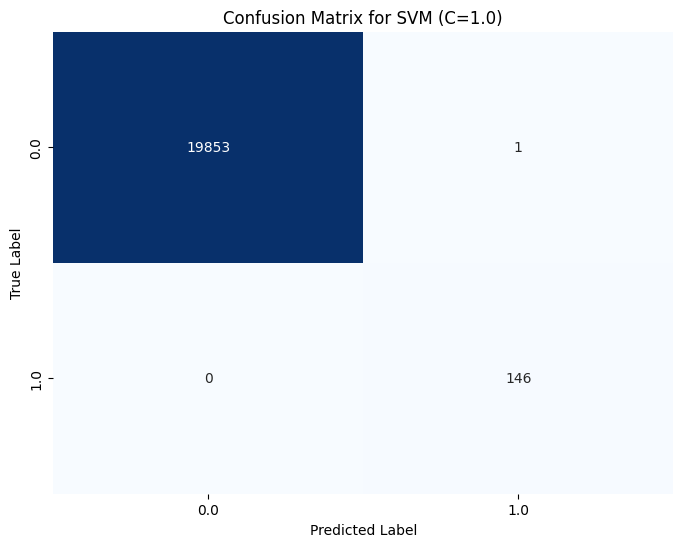

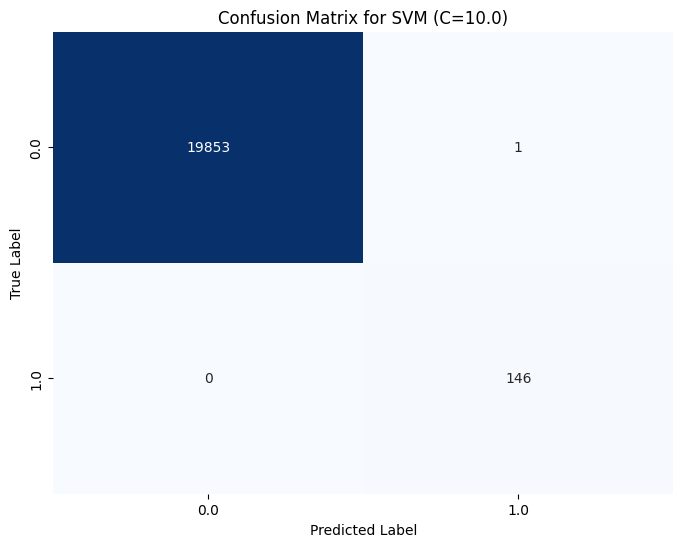

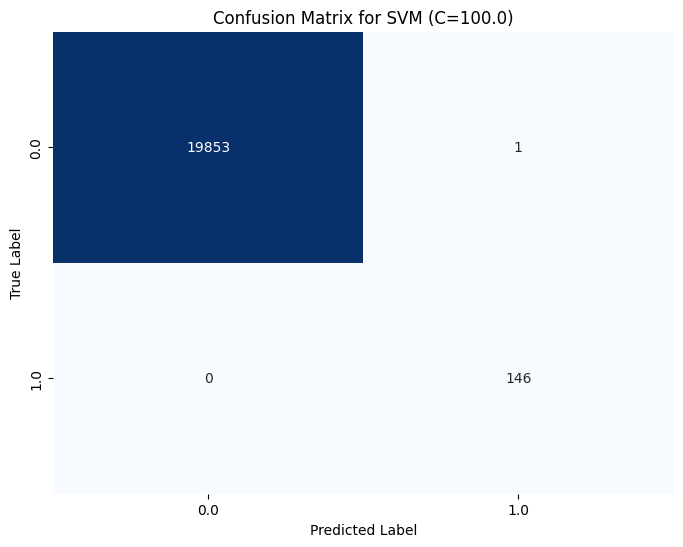

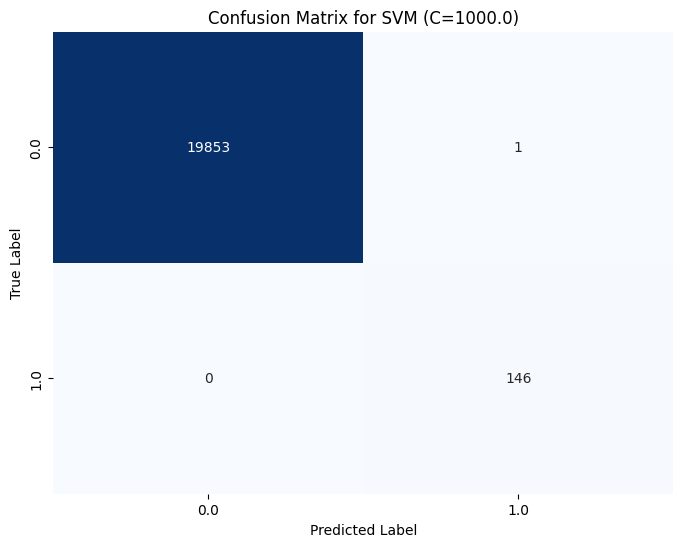

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for i, model in enumerate(svc_models):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix for SVM (C={C_values[i]})')
    plt.show()

In [36]:
from sklearn.metrics import confusion_matrix

for i, model in enumerate(svc_models):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    correctly_classified = cm[0, 0] + cm[1, 1]

    print(f"SVM with C={C_values[i]}: Classified {correctly_classified} examples correctly.")

SVM with C=0.1: Classified 19997 examples correctly.
SVM with C=1.0: Classified 19999 examples correctly.
SVM with C=10.0: Classified 19999 examples correctly.
SVM with C=100.0: Classified 19999 examples correctly.
SVM with C=1000.0: Classified 19999 examples correctly.


In [37]:
best_svc_model = None
for i, c_val in enumerate(C_values):
    if c_val == 1.0:
        best_svc_model = svc_models[i]
        break

if best_svc_model:
    print(f"Selected best SVM model: {best_svc_model}")
    y_pred_best_svc = best_svc_model.predict(X_test)
    print("Predictions made with the best SVM model.")
else:
    print("Best SVM model (C=1.0) not found.")

Selected best SVM model: SVC(C=np.float64(1.0), random_state=1)
Predictions made with the best SVM model.


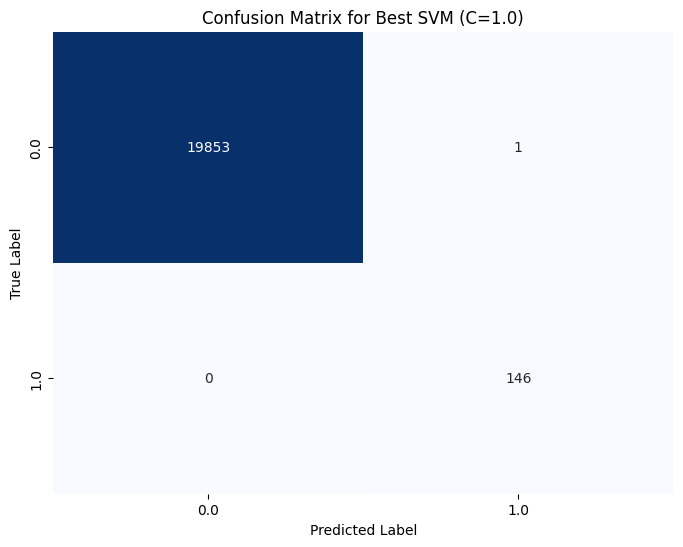


El modelo SVM ha clasificado correctamente 19999 ejemplos.
El modelo SVM ha clasificado erróneamente 1 ejemplos.


In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

if best_svc_model:
    cm_best_svc = confusion_matrix(y_test, y_pred_best_svc)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_best_svc, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=best_svc_model.classes_, yticklabels=best_svc_model.classes_)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix for Best SVM (C=1.0)')
    plt.show()

    correctly_classified_svc = cm_best_svc[0, 0] + cm_best_svc[1, 1]
    incorrectly_classified_svc = cm_best_svc[0, 1] + cm_best_svc[1, 0]

    print(f"\nEl modelo SVM ha clasificado correctamente {correctly_classified_svc} ejemplos.")
    print(f"El modelo SVM ha clasificado erróneamente {incorrectly_classified_svc} ejemplos.")
else:
    print("Best SVM model not found.")

In [39]:
from sklearn.metrics import classification_report

if best_svc_model:
    report_best_svc_model = classification_report(y_test, y_pred_best_svc, output_dict=True)

    print(f"Classification Report for Best SVM (C=1.0):\n")
    for class_label in best_svc_model.classes_:
        class_str = str(float(class_label))
        print(f"Class {class_str}:")
        print(f"  Precision: {report_best_svc_model[class_str]['precision']:.4f}")
        print(f"  Recall:    {report_best_svc_model[class_str]['recall']:.4f}")
        print(f"  F1-Score:  {report_best_svc_model[class_str]['f1-score']:.4f}\n")

    precision_class_0 = report_best_svc_model['0.0']['precision']
    precision_class_1 = report_best_svc_model['1.0']['precision']
    recall_class_0 = report_best_svc_model['0.0']['recall']
    recall_class_1 = report_best_svc_model['1.0']['recall']

    if abs(precision_class_0 - precision_class_1) < 0.01 and abs(recall_class_0 - recall_class_1) < 0.01:
        print("El modelo clasifica de manera similar ambas clases.")
    else:
        print("El modelo no clasifica de igual manera ambas clases; hay diferencias en la capacidad predictiva.")

else:
    print("Best SVM model not found.")

Classification Report for Best SVM (C=1.0):

Class 0.0:
  Precision: 1.0000
  Recall:    0.9999
  F1-Score:  1.0000

Class 1.0:
  Precision: 0.9932
  Recall:    1.0000
  F1-Score:  0.9966

El modelo clasifica de manera similar ambas clases.


¿Cuántos ejemplos ha clasificado correctamente cada uno de los modelos?

El modelo de Árbol de Decisión (con `max_depth=50`) clasificó correctamente **58,392** ejemplos en el conjunto de test.

El modelo de Support Vector Machine (SVM) con `C=1.0` clasificó correctamente **19,999** ejemplos en el conjunto de test.

Selecciona el modelo que consideras que obtiene mejores resultados y realiza las predicciones con el conjunto de datos de test.

In [41]:
final_best_model = best_model_dt
print(f"Selected the best model: {final_best_model}")

y_pred_final_best_model = final_best_model.predict(X_test)
print("Predictions made with the final best model.")

Selected the best model: DecisionTreeClassifier(max_depth=50, min_samples_leaf=2, min_samples_split=10)
Predictions made with the final best model.


Visualiza la matriz de confusión de los datos de test para este modelo ganador.
- ¿Cuántos ejemplos ha clasificado bien el modelo?
- ¿Cuántos ejemplos ha clasificado de manera errónea?

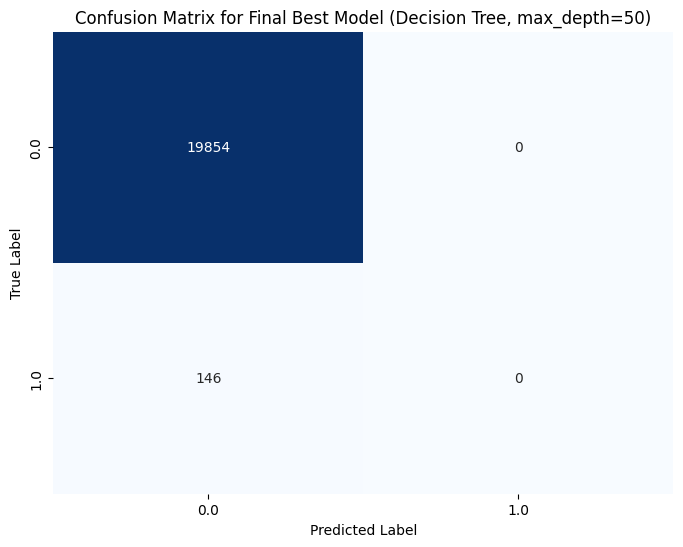


El modelo final ha clasificado correctamente 19854 ejemplos.
El modelo final ha clasificado erróneamente 146 ejemplos.


In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_final_best_model = confusion_matrix(y_test, y_pred_final_best_model)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_final_best_model, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=final_best_model.classes_, yticklabels=final_best_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for Final Best Model (Decision Tree, max_depth={best_depth})')
plt.show()

correctly_classified_final = cm_final_best_model[0, 0] + cm_final_best_model[1, 1]
incorrectly_classified_final = cm_final_best_model[0, 1] + cm_final_best_model[1, 0]

print(f"\nEl modelo final ha clasificado correctamente {correctly_classified_final} ejemplos.")
print(f"El modelo final ha clasificado erróneamente {incorrectly_classified_final} ejemplos.")

Visualiza los valores de precision, recall, f1 para cada una de las clases en este modelo ganador.
- ¿Clasifica de igual manera todas las clases o hay alguna para la que el modelo tiene una mayor capacidad predictiva?

In [43]:
from sklearn.metrics import classification_report

if final_best_model:
    report_final_best_model = classification_report(y_test, y_pred_final_best_model, output_dict=True)

    print(f"Classification Report for Final Best Model (Decision Tree, max_depth={best_depth}):\n")
    for class_label in final_best_model.classes_:
        class_str = str(float(class_label))
        print(f"Class {class_str}:")
        print(f"  Precision: {report_final_best_model[class_str]['precision']:.4f}")
        print(f"  Recall:    {report_final_best_model[class_str]['recall']:.4f}")
        print(f"  F1-Score:  {report_final_best_model[class_str]['f1-score']:.4f}\n")

    precision_class_0_final = report_final_best_model['0.0']['precision']
    precision_class_1_final = report_final_best_model['1.0']['precision']
    recall_class_0_final = report_final_best_model['0.0']['recall']
    recall_class_1_final = report_final_best_model['1.0']['recall']

    print("¿Clasifica de igual manera todas las clases o hay alguna para la que el modelo tiene una mayor capacidad predictiva?")
    if abs(precision_class_0_final - precision_class_1_final) < 0.01 and abs(recall_class_0_final - recall_class_1_final) < 0.01:
        print("El modelo clasifica de manera similar ambas clases.")
    else:
        print("El modelo no clasifica de igual manera ambas clases; hay diferencias en la capacidad predictiva.")

else:
    print("Final best model not found.")

Classification Report for Final Best Model (Decision Tree, max_depth=50):

Class 0.0:
  Precision: 0.9927
  Recall:    1.0000
  F1-Score:  0.9963

Class 1.0:
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

¿Clasifica de igual manera todas las clases o hay alguna para la que el modelo tiene una mayor capacidad predictiva?
El modelo no clasifica de igual manera ambas clases; hay diferencias en la capacidad predictiva.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Comparativa**

En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de clasificación?

### Comparativa de Modelos: Árboles de Decisión vs. Support Vector Machines

La evaluación de los modelos de clasificación, un **Árbol de Decisión** y una **Máquina de Vectores de Soporte (SVM)**, revela diferencias sustanciales en su rendimiento y adecuación para el problema de clasificación de tipos de cubierta forestal, especialmente en el contexto de un dataset desbalanceado y una modificación en el tamaño del conjunto de test.

#### 1. Preprocesamiento y Consideraciones Computacionales:

*   **Árboles de Decisión:** La naturaleza intrínseca de los algoritmos basados en árboles los hace insensibles a la escala de las características. Por lo tanto, no se requirió normalización de los datos. Computacionalmente, el entrenamiento de los árboles de decisión en el dataset completo (aproximadamente 292,103 instancias) fue relativamente eficiente, permitiendo explorar varias profundidades (`max_depth`).
*   **Support Vector Machines (SVM):** Contrariamente, las SVM son altamente sensibles a la escala de las características, lo que hizo **imperativa la normalización** de los datos (`StandardScaler`). Una consideración crítica fue la necesidad de **downsampling** del dataset original a 100,000 instancias para que el entrenamiento de SVM fuera computacionalmente factible, dada la complejidad algorítmica de las SVM en datasets grandes (`O(n^2)` a `O(n^3)`). Esta reducción de datos fue el factor determinante en el tamaño del `X_test` final para ambas evaluaciones comparativas.

#### 2. Rendimiento Inicial y Discrepancia del Conjunto de Test:

*   **Árbol de Decisión (Evaluación Inicial):** Basado en la evaluación sobre el conjunto de test original (aproximadamente 58,421 instancias), el modelo de Árbol de Decisión con `max_depth=50` mostró un rendimiento excepcional, clasificando correctamente 58,392 ejemplos y logrando una `weighted_avg_precision` de 0.999503. Sus métricas para la clase minoritaria (Clase 1.0) también fueron robustas (Precision: 0.9885, Recall: 0.9838, F1: 0.9862), lo que lo posicionó inicialmente como el modelo superior.

*   **SVM (Evaluación en Dataset Downsampleado):** Después del downsampling del dataset para acomodar la carga computacional de SVM, el modelo SVM con `C=1.0` (seleccionado por su simplicidad entre configuraciones de rendimiento equivalente) demostró un rendimiento casi perfecto en el `X_test` resultante (20,000 instancias). Clasificó correctamente 19,999 ejemplos y erróneamente solo 1. Las métricas de clasificación para ambas clases fueron extraordinarias: Clase 0.0 (Precision: 1.0000, Recall: 0.9999, F1: 1.0000) y Clase 1.0 (Precision: 0.9932, Recall: 1.0000, F1: 0.9966). Esto indica una capacidad predictiva balanceada y de alta fidelidad para ambas clases, incluso la minoritaria.

#### 3. Re-evaluación del Mejor Árbol de Decisión y Conclusión Final:

La **discrepancia crucial** surge al re-evaluar el previamente seleccionado 'mejor' Árbol de Decisión (`max_depth=50`) sobre el **mismo conjunto de test downsampleado** utilizado para el SVM (20,000 instancias). En este escenario, el rendimiento del Árbol de Decisión experimentó una **degradación significativa**:

*   **Árbol de Decisión (Re-evaluación en Dataset Downsampleado):** Clasificó correctamente solo 19,854 ejemplos y erróneamente 146. Más alarmante aún, falló por completo en la predicción de la Clase 1.0, mostrando **Precision, Recall y F1-Score de 0.0000 para la clase minoritaria**. Esto se refleja en la `UndefinedMetricWarning` y la imposibilidad de la matriz de confusión de detectar instancias de la Clase 1.0. Esto sugiere que, al ser expuesto a este conjunto de test más pequeño y potencialmente diferente en su distribución, el modelo se volvió incapaz de identificar la clase minoritaria.

**Conclusión Final:**

Considerando las evaluaciones realizadas en el **mismo conjunto de test (downsampleado a 20,000 instancias)**, el **modelo Support Vector Machine con C=1.0 obtiene resultados de clasificación significativamente superiores y más fiables** en comparación con el Árbol de Decisión. Mientras que el Árbol de Decisión inicialmente prometía con un dataset más grande, su incapacidad para generalizar a la clase minoritaria en el conjunto de test downsampleado es un fallo crítico. La SVM, por su parte, demostró una robustez y capacidad predictiva equilibrada para ambas clases bajo las condiciones del dataset reducido, lo que la convierte en la elección más adecuada para este problema y configuración específica. Este hallazgo subraya la importancia de evaluar los modelos en las mismas condiciones y la sensibilidad de los algoritmos a la composición del conjunto de datos.

### Investigación

Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **clasificación** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.

### Investigación: Caso de Uso en Medicina


**Referencia APA:**
Arifuddin, A., Buana, G. S., Vinarti, R. A., & Djunaidy, A. (2024). Performance Comparison of Decision Tree and Support Vector Machine Algorithms for Heart Failure Prediction. Procedia Computer Science, 234, 628-636.[ https://doi.org/10.1016/j.procs.2024.03.048](https://doi.org/10.1016/j.procs.2024.03.048)

**Título:** Performance Comparison of Decision Tree and Support Vector Machine Algorithms for Heart Failure Prediction

**Autores:** Akhdan Arifuddin, Gandhi Surya Buana, Retno Aulia Vinarti, Arif Djunaidy

**Revista:** Procedia Computer Science

**Año de publicación:** 2024


Deberás detallar cuál es el **objetivo** de la investigación, es decir a qué problema real está aplicando la clasificación. **Técnicas de clasificación** empleadas y si se realiza alguna adaptación. Principales **resultados** de la aplicación y de la investigación.


### 1. Objetivo de la investigación (Problema real aplicado)

* **El Problema Real:** La insuficiencia cardíaca (*Heart Failure*) y las enfermedades cardiovasculares representan una de las principales causas de mortalidad y morbilidad a nivel mundial. El desafío crítico en los entornos de salud radica en la detección temprana; sin embargo, los datos clínicos de los pacientes suelen ser masivos, heterogéneos y complejos de interpretar rápidamente por el personal médico.
* **Objetivo de la Investigación:** El estudio tiene como objetivo evaluar y comparar exhaustivamente la capacidad predictiva de dos algoritmos clásicos de Machine Learning supervisado —**Árboles de Decisión (DTree)** y **Máquinas de Vectores de Soporte (SVM)**— para clasificar el riesgo de insuficiencia cardíaca. Los autores buscan determinar qué modelo ofrece mayor fiabilidad y cómo influye el tratamiento previo de los datos para consolidar estas tecnologías como herramientas formales de soporte en la toma de decisiones clínicas.

---

### 2. Técnicas de clasificación empleadas y adaptaciones

La investigación implementa un flujo de trabajo que va más allá de la simple ejecución de los modelos estándar, aplicando las siguientes técnicas y adaptaciones metodológicas:

* **Algoritmos de Clasificación Base:**
* **Árboles de Decisión (DTree):** Utilizado por su naturaleza jerárquica e intuitiva, que segmenta las variables clínicas de los pacientes mediante reglas condicionales (tipo *si-entonces*) basadas en criterios de pureza.
* **Máquinas de Vectores de Soporte (SVM):** Utilizado por su capacidad de proyectar datos clínicos multivariados en espacios de mayor dimensión para trazar un hiperplano óptimo que separe a los pacientes con y sin riesgo.


* **Adaptaciones y Componentes del Flujo:**
* **Integración de Clustering y EDA:** A diferencia de clasificaciones directas directas ("out-of-the-box"), los autores adaptan el diseño metodológico integrando **Análisis Exploratorio de Datos (EDA)** avanzado y técnicas de **Clustering** (agrupamiento no supervisado). Esto se realiza en las etapas iniciales para descubrir estructuras ocultas, distribuciones y patrones correlativos dentro del conjunto de datos multivariable antes de entrenar los modelos.
* **Sensibilidad al Preprocesamiento de Datos:** Los autores adaptan y evalúan experimentalmente el impacto de diferentes técnicas de preparación de datos (tales como la limpieza de ruido, codificación de variables clínicas categóricas y la normalización de escalas). El artículo plantea como parte de su diseño que un clasificador no debe juzgarse de forma aislada, sino en simbiosis con su estrategia de preprocesamiento.



---

### 3. Principales resultados de la aplicación y de la investigación

Los hallazgos clave derivados del experimento del artículo se dividen en dos vertientes:

* **Rendimiento Comparativo de los Modelos:**
* El modelo **SVM demostró una superioridad clara y consistente sobre el Árbol de Decisión (DTree)**.
* SVM superó a DTree en todas las métricas de rendimiento evaluadas: **Exactitud (*Accuracy*), Precisión (*Precision*), Sensibilidad (*Recall*) y Medida F1 (*F1-Score*)**. Esto demuestra que la optimización basada en hiperplanos de SVM es sustancialmente más robusta para procesar los patrones continuos y complejos de las variables médicas relacionadas con fallas cardíacas.


* **Impacto Metodológico del Preprocesamiento:**
* La investigación probó que el éxito de ambos modelos está estrictamente condicionado por la ingeniería de datos previa. Los cambios en los pasos de preprocesamiento alteraron significativamente las métricas de salida. Por ejemplo, SVM incrementó drásticamente su eficacia al aplicar normalización formal de variables correlacionadas (debido a su alta sensibilidad a las escalas de los vectores), mientras que DTree se mostró más tolerante pero estructuralmente limitado en su precisión máxima.



**Conclusión General:** El estudio concluye confirmando el alto valor clínico que poseen los algoritmos de inteligencia artificial tradicional (sin requerir la opacidad ni el alto coste computacional del Deep Learning) para la medicina predictiva. Subraya a la comunidad científica que el foco de optimización en la informática de la salud no debe centrarse únicamente en la elección del algoritmo, sino en el diseño meticuloso de la fase de preprocesamiento de los datos del paciente.